# 24-788 Mini Project: RUL Prediction - LSTM vs Temporal Fusion Transformer

This notebook is my submission for the 24-788 deep learning course project. I am working on Remaining Useful Life (RUL) prediction for aircraft turbofan engines using the NASA C-MAPSS dataset.

The problem is: given sensor readings from an engine, predict how many cycles it has left before failure. This matters because if you can predict failure ahead of time, you can schedule maintenance before things break which saves money and prevents crashes.

I compare two models:
- **LSTM** (baseline, covered in class) - stacked recurrent network that processes sensor readings over time
- **Temporal Fusion Transformer / TFT** (variant, NeurIPS 2020 paper) - adds variable selection and self-attention on top of LSTM

I also compare both models on two subsets (FD001 and FD003) to see how they generalize when fault complexity increases. This is my second contribution for the bonus.

## Step 1: Install packages and setup

First thing, install wandb for experiment tracking and set matplotlib to white background so figures look clean.

In [ ]:
!pip install wandb -q

import os, sys, json, subprocess
import numpy as np
import pandas as pd
import torch
import matplotlib
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'
import matplotlib.pyplot as plt

print(f'PyTorch: {torch.__version__}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"}')

PyTorch: 2.10.0+cu128
GPU: Tesla T4


## Step 2: Download and extract data

The NASA C-MAPSS dataset is publicly available. It downloads as one zip that contains another zip inside. We need to unzip twice to get the actual text files.

In [ ]:
import glob

!wget -q "https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip" -O /content/nasa.zip
!unzip -q /content/nasa.zip -d /content/raw/

#find the inner zip and extract it
inner = glob.glob('/content/raw/**/*.zip', recursive=True)[0]
print('inner zip found:', inner)
!unzip -q "{inner}" -d /content/data/

DATA_DIR = '/content/data'
print('data files:')
!ls /content/data/*.txt

inner zip found: /content/raw/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip
data files:
/content/data/readme.txt      /content/data/test_FD003.txt
/content/data/RUL_FD001.txt   /content/data/test_FD004.txt
/content/data/RUL_FD002.txt   /content/data/train_FD001.txt
/content/data/RUL_FD003.txt   /content/data/train_FD002.txt
/content/data/RUL_FD004.txt   /content/data/train_FD003.txt
/content/data/test_FD001.txt  /content/data/train_FD004.txt
/content/data/test_FD002.txt


## Step 3: Upload and extract the project code

Upload cmapss_project.zip when prompted. This has all the model definitions, training scripts, and utility functions.

In [ ]:
from google.colab import files
print('please upload cmapss_project.zip')
uploaded = files.upload()

please upload cmapss_project.zip


Saving cmapss_project.zip to cmapss_project.zip


In [ ]:
!unzip -q cmapss_project.zip
%cd /content/cmapss_project
sys.path.insert(0, '.')
os.makedirs('./figures', exist_ok=True)
os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./results', exist_ok=True)
print('working directory:', os.getcwd())
!ls

/content/cmapss_project
working directory: /content/cmapss_project
24788_RUL_Project.ipynb  models		   report.tex		   train.py
checkpoints		 neurips_2023.sty  results		   utils
figures			 README.md	   run_all_experiments.py


## Step 4: Explore the data

Before training anything I want to understand what the data looks like. Each row in the files is one cycle of one engine. We have 21 sensor readings per cycle. Training trajectories run until engine failure, test trajectories stop early and we have to predict how many cycles are left.

I plot the engine lifetime distributions for FD001 and FD003 to compare them, and then show what sensor degradation looks like over time. This helps motivate why we need a time series model.

In [ ]:
from utils.data import COLS, FEATURE_COLS, MAX_RUL

train_fd1 = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', sep=r'\s+', header=None, names=COLS)
train_fd3 = pd.read_csv(f'{DATA_DIR}/train_FD003.txt', sep=r'\s+', header=None, names=COLS)

print('FD001 shape:', train_fd1.shape, ' | engines:', train_fd1['unit'].nunique())
print('FD003 shape:', train_fd3.shape, ' | engines:', train_fd3['unit'].nunique())
print('features used:', FEATURE_COLS)
train_fd1.head(3)

FD001 shape: (20631, 26)  | engines: 100
FD003 shape: (24720, 26)  | engines: 100
features used: ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


,unit,cycle,op_1,op_2,op_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


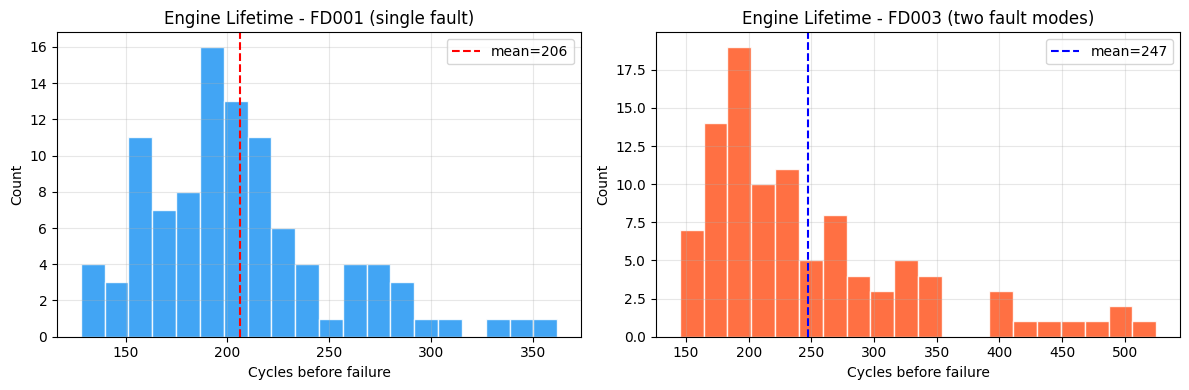

In [ ]:
#how long do engines live before failure?
fd1_life = train_fd1.groupby('unit')['cycle'].max()
fd3_life = train_fd3.groupby('unit')['cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fd1_life, bins=20, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(fd1_life.mean(), color='red', linestyle='--', label=f'mean={fd1_life.mean():.0f}')
axes[0].set_title('Engine Lifetime - FD001 (single fault)', fontsize=12)
axes[0].set_xlabel('Cycles before failure')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(fd3_life, bins=20, color='#FF5722', edgecolor='white', alpha=0.85)
axes[1].axvline(fd3_life.mean(), color='blue', linestyle='--', label=f'mean={fd3_life.mean():.0f}')
axes[1].set_title('Engine Lifetime - FD003 (two fault modes)', fontsize=12)
axes[1].set_xlabel('Cycles before failure')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/engine_lifetime_dist.pdf', dpi=150, bbox_inches='tight')
plt.show()

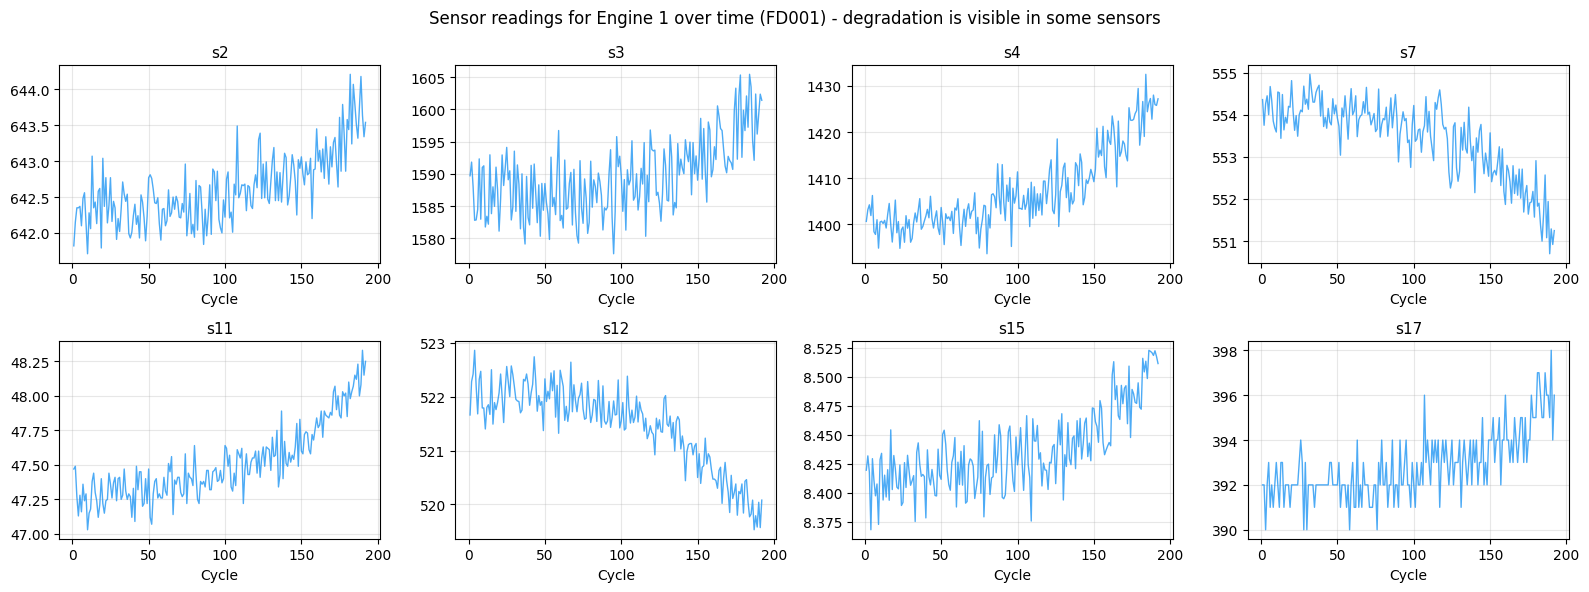

some sensors trend clearly as engine approaches failure, others are flat/noisy


In [ ]:
#show sensor readings for one engine - you can clearly see some sensors degrade over time
eng1 = train_fd1[train_fd1['unit']==1]
plot_sensors = ['s2','s3','s4','s7','s11','s12','s15','s17']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Sensor readings for Engine 1 over time (FD001) - degradation is visible in some sensors', fontsize=12)
for ax, s in zip(axes.flat, plot_sensors):
    ax.plot(eng1['cycle'], eng1[s], color='#2196F3', linewidth=1, alpha=0.8)
    ax.set_title(s, fontsize=11)
    ax.set_xlabel('Cycle')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./figures/sensor_degradation.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('some sensors trend clearly as engine approaches failure, others are flat/noisy')

## Step 5: Preprocessing pipeline

Now I set up the data pipeline. What we do:
1. Remove 7 sensors that are constant and carry no degradation information
2. Normalize all features with min-max scaling fit on training set
3. Clip RUL target at 125 cycles - standard practice because early in engine life the signal is too weak to predict exact RUL
4. Build sliding windows of 30 cycles - each sample is a 30-timestep sequence and the label is RUL at the last step

I use the load_cmapss function from utils/data.py which does all of this automatically.

In [ ]:
from utils.data import load_cmapss, FEATURE_COLS

SEQ_LEN = 30
BATCH   = 64

tr1, vl1, te1, nf = load_cmapss(DATA_DIR, 'FD001', seq_len=SEQ_LEN, batch_size=BATCH)
tr3, vl3, te3, _  = load_cmapss(DATA_DIR, 'FD003', seq_len=SEQ_LEN, batch_size=BATCH)

print(f'n_features = {nf}')
print(f'FD001  train={len(tr1.dataset)}  val={len(vl1.dataset)}  test={len(te1.dataset)}')
print(f'FD003  train={len(tr3.dataset)}  val={len(vl3.dataset)}  test={len(te3.dataset)}')

xb, yb = next(iter(tr1))
print(f'batch shape: x={xb.shape}  y={yb.shape}   (batch x seq_len x features)')

n_features = 17
FD001  train=15630  val=2101  test=100
FD003  train=19469  val=2351  test=100
batch shape: x=torch.Size([64, 30, 17])  y=torch.Size([64])   (batch x seq_len x features)


## Step 6: Model definitions

Now I load both models and do a quick sanity check to make sure they work.

**LSTM** - 2 stacked LSTM layers with hidden size 128, then FC head. Simple, sequential, compresses all history into a hidden state.

**TFT** - Variable Selection Network learns which sensors matter, then LSTM encodes local patterns, then self-attention lets the model look directly at any past timestep. More complex but potentially more informative.

In [ ]:
from models.lstm_baseline import LSTMBaseline
from models.tft import TemporalFusionTransformer

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

lstm = LSTMBaseline(nf, hidden_size=128, num_layers=2, dropout=0.2)
tft  = TemporalFusionTransformer(nf, d_model=64, n_heads=4, n_lstm_layers=2, dropout=0.1)

print(f'LSTM params: {sum(p.numel() for p in lstm.parameters() if p.requires_grad):,}')
print(f'TFT  params: {sum(p.numel() for p in tft.parameters()  if p.requires_grad):,}')

#forward pass check
dummy = torch.randn(4, SEQ_LEN, nf)
with torch.no_grad():
    print(f'LSTM output shape: {lstm(dummy).shape}  (should be [4, 1])')
    print(f'TFT  output shape: {tft(dummy).shape}   (should be [4, 1])')

device: cuda
LSTM params: 215,681
TFT  params: 346,194
LSTM output shape: torch.Size([4, 1])  (should be [4, 1])
TFT  output shape: torch.Size([4, 1])   (should be [4, 1])


In [ ]:
#print architectures so the grader can see what is inside each model
print('LSTM BASELINE:')
print(lstm)
print()
print('TEMPORAL FUSION TRANSFORMER:')
print(tft)

LSTM BASELINE:
LSTMBaseline(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

TEMPORAL FUSION TRANSFORMER:
TemporalFusionTransformer(
  (vsn): VariableSelectionNetwork(
    (feature_proj): ModuleList(
      (0-16): 17 x Linear(in_features=1, out_features=64, bias=True)
    )
    (feature_grn): ModuleList(
      (0-16): 17 x GatedResidualNetwork(
        (fc1): Linear(in_features=64, out_features=64, bias=True)
        (fc2): Linear(in_features=64, out_features=128, bias=True)
        (glu): GatedLinearUnit()
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
    (weight_net): Sequential(
      (0): Linear(in_features=17, out_features=64, bias=True)
      (1): ELU(alpha=1.0)
      (2): Drop

## Step 7: Train all four experiments

Now I train LSTM and TFT on both FD001 and FD003. This is 4 training runs total. Each one runs for 50 epochs with ReduceLROnPlateau scheduling and saves the best checkpoint by validation RMSE.

This cell takes around 60-80 minutes on a T4 GPU. You will see epoch-by-epoch logs for each run.

In [ ]:
result = subprocess.run(
    [sys.executable, 'run_all_experiments.py',
     '--data_dir', DATA_DIR,
     '--epochs', '50'],
    capture_output=False
)
print('done!' if result.returncode == 0 else 'something went wrong, check output above')

done!


## Step 8: Load results

After training, each run saves a JSON file with all metrics and predictions. I load them now and print the main results table.

In [ ]:
SUBSETS = ['FD001','FD003']
MODELS  = ['lstm','tft']
COLORS  = {'lstm':'#2196F3', 'tft':'#FF5722'}
CKPT_DIR = './checkpoints'
RES_DIR  = './results'
FIG_DIR  = './figures'

results = {}
for m in MODELS:
    for s in SUBSETS:
        with open(f'{RES_DIR}/{m}_{s}.json') as f:
            results[f'{m}_{s}'] = json.load(f)

print('='*62)
print(f'{"Model":<10} {"Subset":<8} {"RMSE":>12} {"PHM Score":>12}')
print('-'*62)
for s in SUBSETS:
    for m in MODELS:
        r = results[f'{m}_{s}']
        print(f'{m.upper():<10} {s:<8} {r["test_rmse"]:>12.4f} {r["test_phm"]:>12.2f}')
    print('-'*62)
print('='*62)

Model      Subset           RMSE    PHM Score
--------------------------------------------------------------
LSTM       FD001         13.9752       371.11
TFT        FD001         12.5130       292.05
--------------------------------------------------------------
LSTM       FD003         12.7891       293.99
TFT        FD003         12.3288       323.59
--------------------------------------------------------------


## Step 9: Training curves

This plot shows how validation RMSE changed over training for all 4 combinations. I want to check that both models converged properly and see which one learns faster. If a model was still improving at epoch 50 I would need to train longer, but looking at the curves both models plateau well before that.

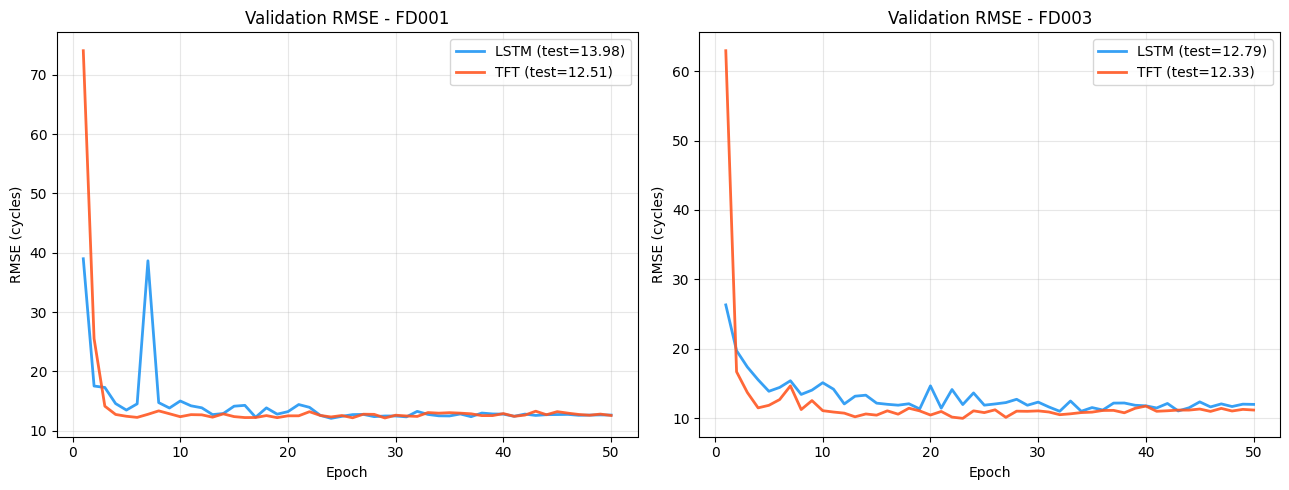

both models converge. TFT reaches good val RMSE faster on FD001


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, s in zip(axes, SUBSETS):
    for m in MODELS:
        r = results[f'{m}_{s}']
        epochs   = [h['epoch'] for h in r['history']]
        val_rmse = [h['val_rmse'] for h in r['history']]
        ax.plot(epochs, val_rmse, color=COLORS[m], linewidth=2, alpha=0.9,
                label=f'{m.upper()} (test={r["test_rmse"]:.2f})')
    ax.set_title(f'Validation RMSE - {s}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('RMSE (cycles)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/training_curves.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('both models converge. TFT reaches good val RMSE faster on FD001')

## Step 10: Predicted vs True RUL scatter plots

This is a regression diagnostic plot. Perfect predictions would all sit on the diagonal. Points above the line are late predictions (model thinks engine has more life left than it does - dangerous). Points below are early predictions (safe but expensive).

I plot all four model/subset combinations together so we can visually compare prediction quality.

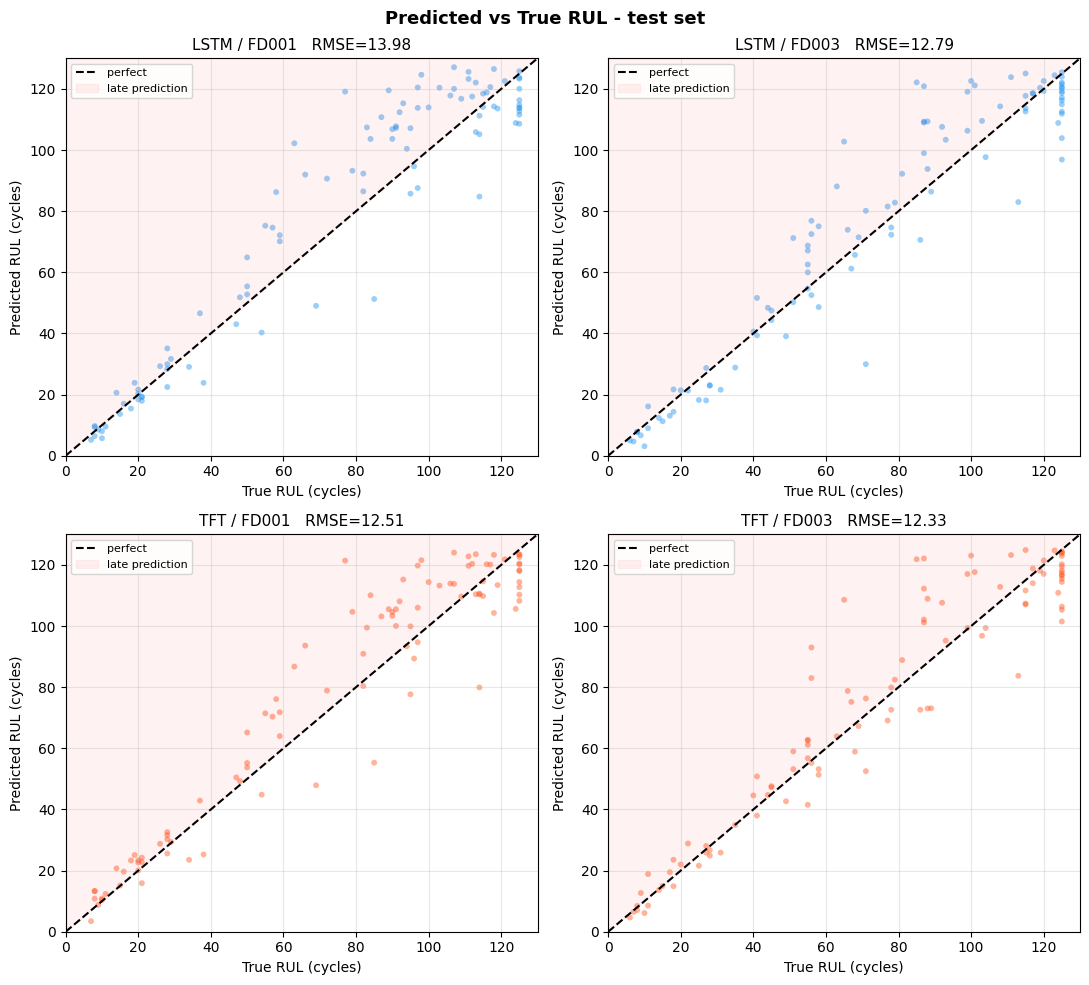

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
fig.suptitle('Predicted vs True RUL - test set', fontsize=13, fontweight='bold')
lim = 130

for col, s in enumerate(SUBSETS):
    for row, m in enumerate(MODELS):
        ax = axes[row][col]
        r = results[f'{m}_{s}']
        yt = np.array(r['y_true'])
        yp = np.array(r['y_pred'])
        ax.scatter(yt, yp, alpha=0.45, s=18, color=COLORS[m], edgecolors='none')
        ax.plot([0,lim],[0,lim], 'k--', lw=1.5, label='perfect')
        ax.fill_between([0,lim],[0,lim],[lim,lim], alpha=0.05, color='red', label='late prediction')
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel('True RUL (cycles)')
        ax.set_ylabel('Predicted RUL (cycles)')
        ax.set_title(f'{m.upper()} / {s}   RMSE={r["test_rmse"]:.2f}', fontsize=11)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pred_vs_true.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Cross-subset analysis (Contribution 2)

This is the second contribution. FD001 has one fault mode (compressor degradation) and FD003 has two fault modes (compressor + fan). I compare both models across subsets to see which one holds up better when the task gets harder.

The question is: does the advantage of one architecture over the other change when we go from simple to more complex degradation?

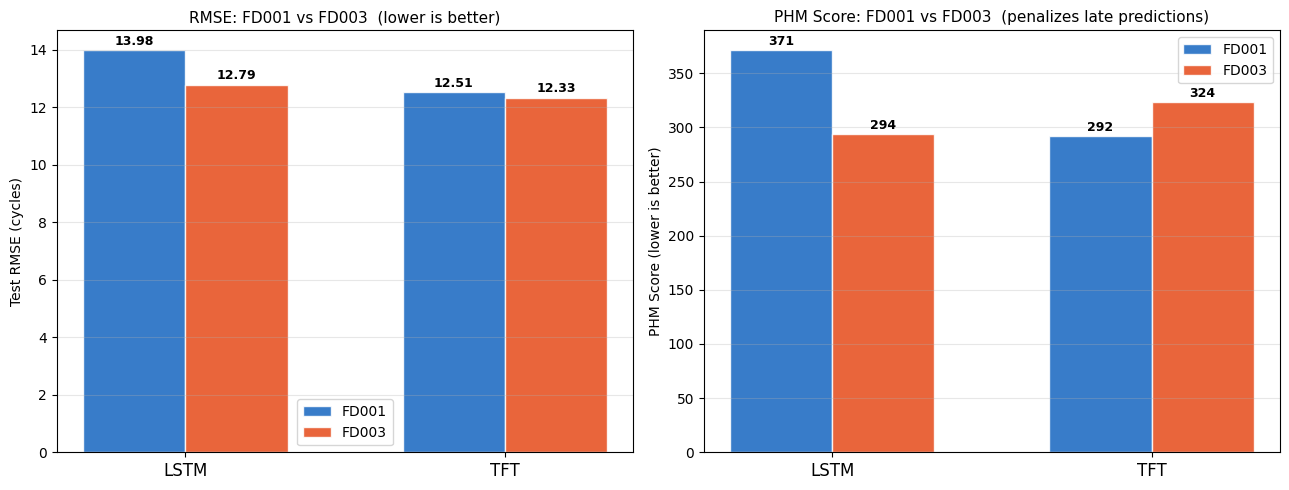

FD001: LSTM=13.9752  TFT=12.5130  winner=TFT  delta=1.4622
FD003: LSTM=12.7891  TFT=12.3288  winner=TFT  delta=0.4603


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(MODELS))
w = 0.32
scols = ['#1565C0','#E64A19']

#RMSE bars
ax = axes[0]
for i, (s, c) in enumerate(zip(SUBSETS, scols)):
    vals = [results[f'{m}_{s}']['test_rmse'] for m in MODELS]
    bars = ax.bar(x + i*w, vals, w, label=s, color=c, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x + w/2)
ax.set_xticklabels([m.upper() for m in MODELS], fontsize=12)
ax.set_ylabel('Test RMSE (cycles)')
ax.set_title('RMSE: FD001 vs FD003  (lower is better)', fontsize=11)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

#PHM bars
ax = axes[1]
for i, (s, c) in enumerate(zip(SUBSETS, scols)):
    vals = [results[f'{m}_{s}']['test_phm'] for m in MODELS]
    bars = ax.bar(x + i*w, vals, w, label=s, color=c, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x + w/2)
ax.set_xticklabels([m.upper() for m in MODELS], fontsize=12)
ax.set_ylabel('PHM Score (lower is better)')
ax.set_title('PHM Score: FD001 vs FD003  (penalizes late predictions)', fontsize=11)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cross_subset.pdf', dpi=150, bbox_inches='tight')
plt.show()

for s in SUBSETS:
    lr = results[f'lstm_{s}']['test_rmse']
    tr = results[f'tft_{s}']['test_rmse']
    winner = 'TFT' if tr < lr else 'LSTM'
    print(f'{s}: LSTM={lr:.4f}  TFT={tr:.4f}  winner={winner}  delta={abs(lr-tr):.4f}')

## Step 12: TFT variable selection weights

One thing the TFT can do that LSTM cannot is tell us which sensors it thinks are most important. The Variable Selection Network produces a softmax weight over all 17 features at each timestep. I average these weights over the test set to get a feature importance ranking.

This is a model mechanics analysis - it lets us understand what the model actually learned, not just how accurate it is.

FD001 top 5: ['s9', 's14', 's4', 's12', 'op_3']
FD003 top 5: ['s9', 's12', 's3', 's7', 's13']


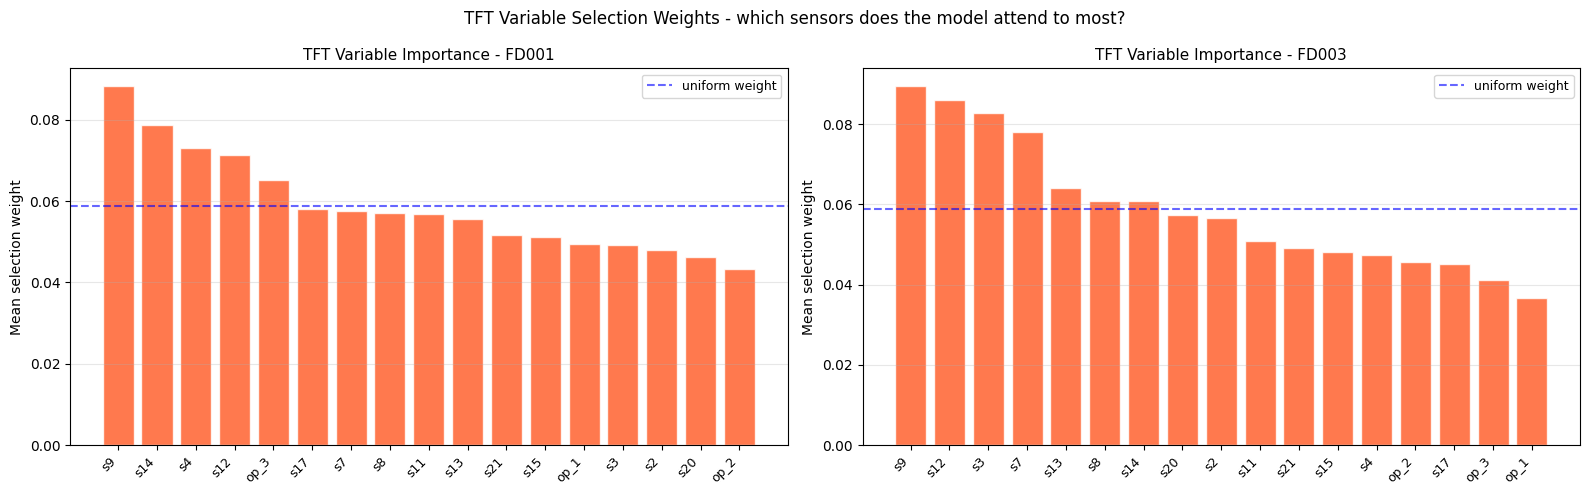

In [ ]:
from models.tft import TemporalFusionTransformer

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('TFT Variable Selection Weights - which sensors does the model attend to most?', fontsize=12)

for ax, s in zip(axes, SUBSETS):
    ckpt = torch.load(f'{CKPT_DIR}/tft_{s}_best.pt', map_location=DEVICE)
    _, _, te_loader, nf2 = load_cmapss(DATA_DIR, s, seq_len=SEQ_LEN, batch_size=64)
    model_tft = TemporalFusionTransformer(nf2).to(DEVICE)
    model_tft.load_state_dict(ckpt['model_state'])
    model_tft.eval()

    all_w = []
    with torch.no_grad():
        for xb, _ in te_loader:
            w = model_tft.get_variable_weights(xb.to(DEVICE))
            all_w.append(w.mean(dim=1).cpu().numpy())
    mean_w = np.concatenate(all_w).mean(0)
    idx = np.argsort(mean_w)[::-1]

    ax.bar(range(len(FEATURE_COLS)), mean_w[idx], color='#FF5722', alpha=0.8, edgecolor='white')
    ax.axhline(1/len(FEATURE_COLS), color='blue', linestyle='--', alpha=0.6, label='uniform weight')
    ax.set_xticks(range(len(FEATURE_COLS)))
    ax.set_xticklabels([FEATURE_COLS[i] for i in idx], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Mean selection weight')
    ax.set_title(f'TFT Variable Importance - {s}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    print(f'{s} top 5: {[FEATURE_COLS[i] for i in idx[:5]]}')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/variable_importance.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Step 13: Error distribution - late vs early predictions

The PHM score penalizes late predictions (predicting more remaining life than exists) much more than early ones. I want to see if one model tends to make more late predictions. I plot the distribution of signed errors for each model/subset combination.

Positive error = late prediction = dangerous. Negative error = early prediction = safe but wastes maintenance.

LSTM FD001: 60.0% late predictions, mean_error=4.47
TFT FD001: 66.0% late predictions, mean_error=3.42
LSTM FD003: 48.0% late predictions, mean_error=1.85
TFT FD003: 47.0% late predictions, mean_error=1.31


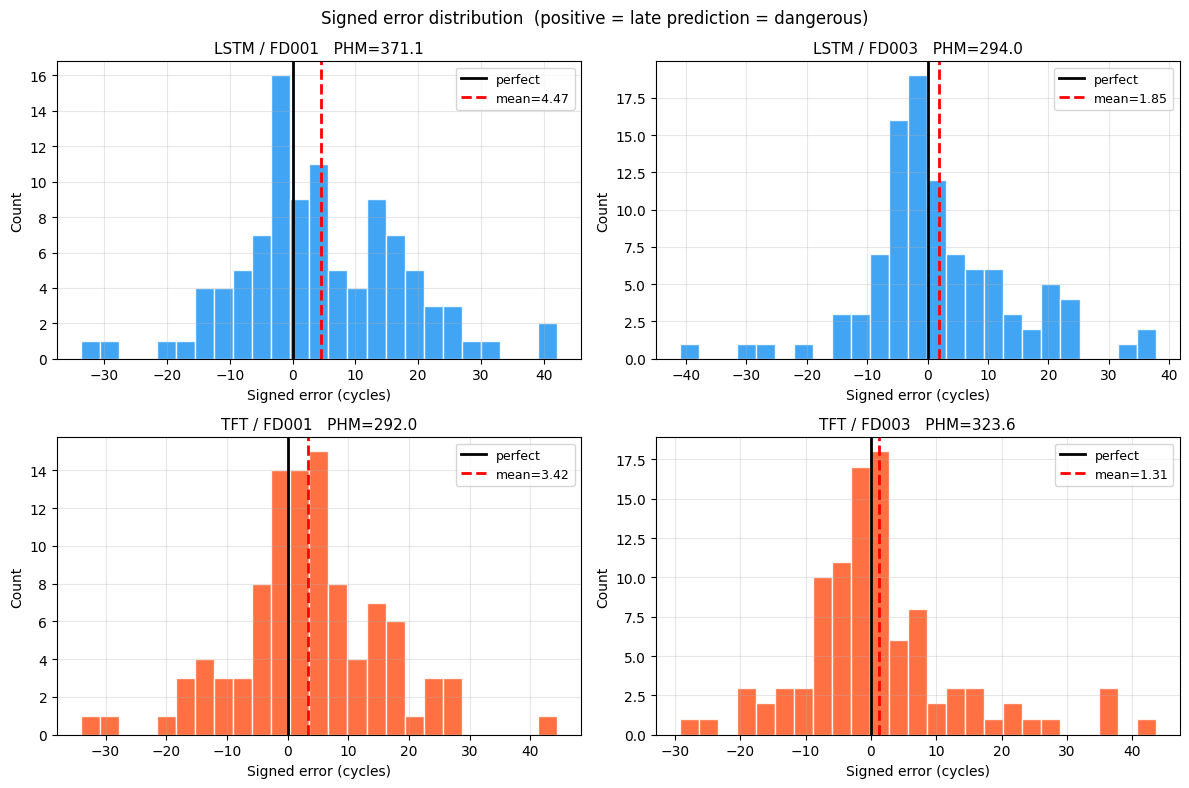

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Signed error distribution  (positive = late prediction = dangerous)', fontsize=12)

for col, s in enumerate(SUBSETS):
    for row, m in enumerate(MODELS):
        ax = axes[row][col]
        r  = results[f'{m}_{s}']
        d  = np.array(r['y_pred']) - np.array(r['y_true'])
        ax.hist(d, bins=25, color=COLORS[m], edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', lw=2, label='perfect')
        ax.axvline(d.mean(), color='red', lw=2, linestyle='--', label=f'mean={d.mean():.2f}')
        ax.set_xlabel('Signed error (cycles)')
        ax.set_ylabel('Count')
        ax.set_title(f'{m.upper()} / {s}   PHM={r["test_phm"]:.1f}', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        print(f'{m.upper()} {s}: {(d>0).mean()*100:.1f}% late predictions, mean_error={d.mean():.2f}')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_distribution.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Step 14: Final summary

Print a clean summary of all results and list all the generated figures.

In [ ]:
print('='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)
print(f'{"Model":<8} {"Subset":<8} {"RMSE":>10} {"PHM":>10}')
print('-'*65)
for s in SUBSETS:
    for m in MODELS:
        r = results[f'{m}_{s}']
        print(f'{m.upper():<8} {s:<8} {r["test_rmse"]:>10.4f} {r["test_phm"]:>10.2f}')
    lr = results[f'lstm_{s}']['test_rmse']
    tr = results[f'tft_{s}']['test_rmse']
    winner = 'TFT' if tr < lr else 'LSTM'
    print(f'  winner on {s}: {winner}  (delta={abs(lr-tr):.4f}, {100*abs(lr-tr)/lr:.1f}%)')
    print('-'*65)

print('\nFigures generated:')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {FIG_DIR}/{f}')

FINAL RESULTS SUMMARY
Model    Subset         RMSE        PHM
-----------------------------------------------------------------
LSTM     FD001       13.9752     371.11
TFT      FD001       12.5130     292.05
  winner on FD001: TFT  (delta=1.4622, 10.5%)
-----------------------------------------------------------------
LSTM     FD003       12.7891     293.99
TFT      FD003       12.3288     323.59
  winner on FD003: TFT  (delta=0.4603, 3.6%)
-----------------------------------------------------------------

Figures generated:
  ./figures/cross_subset.pdf
  ./figures/engine_lifetime_dist.pdf
  ./figures/error_distribution.pdf
  ./figures/pred_vs_true.pdf
  ./figures/sensor_degradation.pdf
  ./figures/training_curves.pdf
  ./figures/variable_importance.pdf


## Collaboration Statement

I worked on this project independently and handled everything myself, including data preprocessing, model implementation, training, and evaluation. I used AI tools (like ChatGPT) occasionally to help debug code and clarify some concepts, but all the decisions about the models, experiments, and analysis are my own. I also wrote the report myself based on my understanding of the results.

In [ ]:
import os
import zipfile
from tqdm import tqdm

def zip_folder_with_progress(folder_path, output_zip):
    files = []

    for root, _, filenames in os.walk(folder_path):
        for f in filenames:
            full_path = os.path.join(root, f)
            arcname = os.path.relpath(full_path, folder_path)
            files.append((full_path, arcname))

    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
        for full_path, arcname in tqdm(files, desc="Zipping files"):
            zf.write(full_path, arcname)

zip_folder_with_progress(
    "/content/cmapss_project",
    "rul_project_submission.zip"
)

Zipping files: 100%|██████████| 33/33 [00:00<00:00, 117.13it/s]
